# Baseline TabDDPM - Shared Schedule

This is the **reference method**: standard TabDDPM with a single linear noise schedule applied identically to every categorical feature, regardless of its cardinality K. All other methods (`04`, `05`) are evaluated against the metrics this notebook produces.

Pipeline: load data → build schedule → train MLP → sample → evaluate → save metrics.

## Setup

In [ ]:
# Ensure the notebook runs from the project root, regardless of how Jupyter
# was launched. This makes every `data/...`, `outputs/...`, `src/...` path work.
import os, sys, importlib
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')
sys.path.insert(0, str(Path.cwd()))

import json, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import src.data_utils, src.mlp, src.gaussian_diffusion, src.multinomial_diffusion
import src.sampling, src.train, src.eval_metrics, src.schedule_utils
for m in [src.data_utils, src.mlp, src.gaussian_diffusion, src.multinomial_diffusion,
          src.schedule_utils, src.sampling, src.train, src.eval_metrics]:
    importlib.reload(m)

from src.data_utils            import load_split, load_meta, CAT_COLS
from src.mlp                   import TabDDPMMLP
from src.gaussian_diffusion    import GaussianDiffusion
from src.multinomial_diffusion import MultinomialDiffusion
from src.sampling              import sample
from src.train                 import train, make_dataloader
from src.eval_metrics          import per_column_jsd, correlation_l2, tstr

plt.rcParams['figure.dpi']   = 110
plt.rcParams['axes.grid']    = True
plt.rcParams['grid.alpha']   = 0.3
plt.rcParams['savefig.dpi']  = 150

In [2]:
# ---- experiment config ----
METHOD          = "baseline"
SEED            = 42
N_TRAIN_STEPS   = 50000
N_SAMPLES       = 10000
T               = 1000           # diffusion timesteps
BATCH_SIZE      = 256
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
LAMBDA_MN       = 1.0
AUX_WEIGHT      = 1.0            # auxiliary CE loss weight for categoricals
GRAD_CLIP       = 1.0
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"

ADDITIONAL_SEEDS = [1, 7]        # run multi-seed loop at the end (set to [] to skip)

# ---- paths (project-root relative; setup cell ensures cwd is project root) ----
METRICS_PATH = Path(f"outputs/metrics/{METHOD}_seed{SEED}.json")
CKPT_PATH    = Path(f"outputs/checkpoints/{METHOD}_seed{SEED}.pt")
FIG_DIR      = Path("outputs/figures")
for p in (METRICS_PATH.parent, CKPT_PATH.parent, FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

print(f"method = {METHOD}")
print(f"seed   = {SEED}")
print(f"device = {DEVICE}")
print(f"output → {METRICS_PATH}")

method = baseline
seed   = 42
device = cuda
output → outputs/metrics/baseline_seed42.json


## 1. Load Data

In [3]:
meta          = load_meta()
cardinalities = meta["cardinalities"]
print(f"cardinalities: {cardinalities}")
print(f"numerical columns: {meta['n_num']}")
print(f"train size: {meta['split_sizes']['train']:,}   "
      f"val: {meta['split_sizes']['val']:,}   test: {meta['split_sizes']['test']:,}")


cardinalities: [7, 16, 7, 14, 6, 5, 2, 41]
numerical columns: 6
train size: 36,177   val: 4,522   test: 4,523


## 2. Build the Noise Schedule

Shared linear schedule for all categorical features:

$$\beta_t \in [10^{-4},\, 0.02], \quad T = 1000, \quad \bar{\alpha}_t = \prod_{s=1}^t (1 - \beta_s)$$


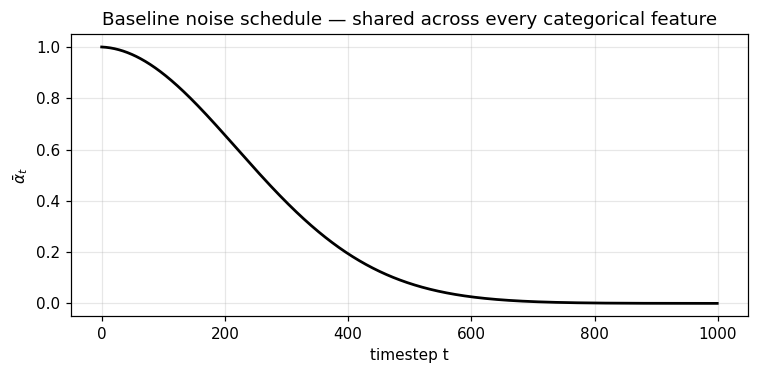

In [4]:
torch.manual_seed(SEED)
np.random.seed(SEED)

gauss_diff = GaussianDiffusion(n_steps=T, device=DEVICE)
mn_diff    = MultinomialDiffusion(cardinalities, n_steps=T, device=DEVICE,
                                  aux_weight=AUX_WEIGHT)

# Visualise the (single, shared) schedule
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(gauss_diff.alpha_bars.cpu(), color='black', lw=1.8)
ax.set_xlabel("timestep t");  ax.set_ylabel(r"$\bar{\alpha}_t$")
ax.set_title("Baseline noise schedule - shared across every categorical feature")
plt.tight_layout(); plt.show()

## 3. Train

Hybrid loss combining Gaussian and multinomial objectives:

$$\mathcal{L} = \underbrace{\|\epsilon - \epsilon_\theta(x_t, t)\|^2}_{\text{numericals (MSE)}} + \lambda \cdot \underbrace{D_{\text{KL}}\!\left[q(x_{t-1}|x_t, x_0) \,\|\, p_\theta(x_{t-1}|x_t)\right]}_{\text{categoricals (VLB)}}$$

AdamW with cosine annealing, gradient clipping at 1.0, and weight decay $10^{-4}$.


In [5]:
train_loader = make_dataloader(load_split("train"), batch_size=BATCH_SIZE)

model = TabDDPMMLP(
    n_num=meta["n_num"], cardinalities=cardinalities, n_classes=2,
    hidden_dim=256, n_layers=3, t_emb_dim=128,
)
n_params = sum(p.numel() for p in model.parameters())
print(f"model parameters: {n_params:,}")

t0 = time.time()
losses = train(
    model, gauss_diff, mn_diff, train_loader,
    n_steps=N_TRAIN_STEPS, lr=LR,
    weight_decay=WEIGHT_DECAY, lambda_mn=LAMBDA_MN,
    grad_clip=GRAD_CLIP, log_every=5000,
    device=DEVICE, seed=SEED,
)
train_time = time.time() - t0
print(f"\ntraining time: {train_time/60:.1f} min "
      f"({train_time/N_TRAIN_STEPS*1000:.1f} ms/step)")

torch.save({"model": model.state_dict()}, str(CKPT_PATH))
print(f"checkpoint saved → {CKPT_PATH}")

model parameters: 580,712
  step   5000  loss=1.1436  (g=0.2030  m=0.9406)  194.2s
  step  10000  loss=1.1057  (g=0.1816  m=0.9241)  384.4s
  step  15000  loss=1.0980  (g=0.1766  m=0.9214)  561.7s
  step  20000  loss=1.0904  (g=0.1715  m=0.9188)  740.0s
  step  25000  loss=1.0827  (g=0.1666  m=0.9161)  923.0s
  step  30000  loss=1.0785  (g=0.1631  m=0.9154)  1111.0s
  step  35000  loss=1.0738  (g=0.1602  m=0.9136)  1291.4s
  step  40000  loss=1.0693  (g=0.1585  m=0.9108)  1471.0s
  step  45000  loss=1.0676  (g=0.1566  m=0.9110)  1652.4s
  step  50000  loss=1.0657  (g=0.1557  m=0.9100)  1821.8s

training time: 30.4 min (36.5 ms/step)
checkpoint saved → outputs/checkpoints/baseline_seed42.pt


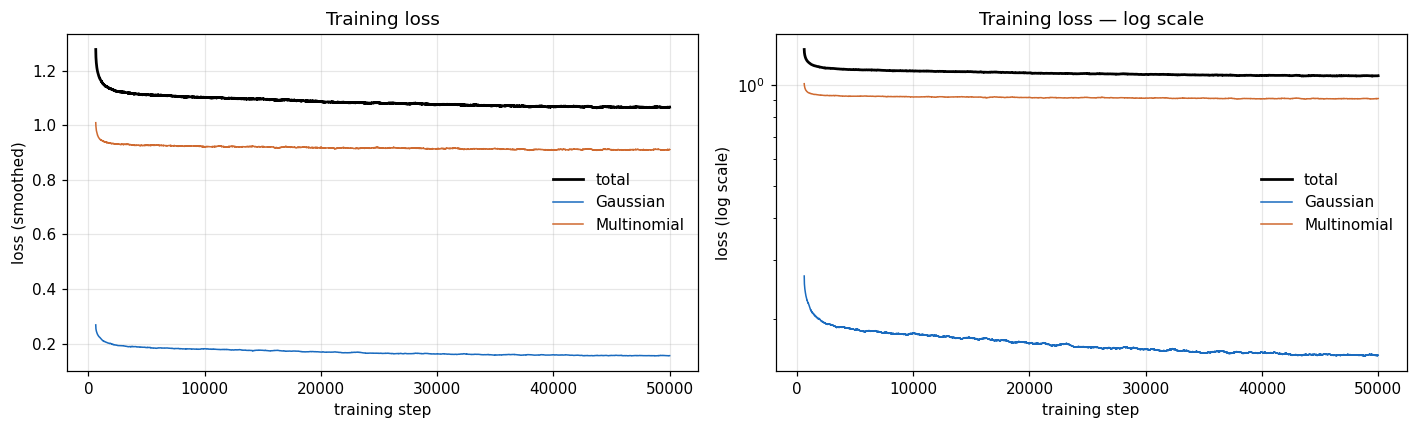

In [6]:
losses_arr = np.array([[l[0], l[1], l[2], l[3]] for l in losses])
window = max(1, len(losses_arr) // 80)
def smooth(y): return np.convolve(y, np.ones(window)/window, mode='valid')
xs = np.arange(window-1, len(losses_arr))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(xs, smooth(losses_arr[:, 1]), color='black', lw=1.8, label='total')
axes[0].plot(xs, smooth(losses_arr[:, 2]), color='#1a6bbf', lw=1.0, label='Gaussian')
axes[0].plot(xs, smooth(losses_arr[:, 3]), color='#cf6a30', lw=1.0, label='Multinomial')
axes[0].set_xlabel("training step");  axes[0].set_ylabel("loss (smoothed)")
axes[0].set_title("Training loss"); axes[0].legend(frameon=False)

axes[1].semilogy(xs, smooth(losses_arr[:, 1]), color='black', lw=1.8, label='total')
axes[1].semilogy(xs, smooth(losses_arr[:, 2]), color='#1a6bbf', lw=1.0, label='Gaussian')
axes[1].semilogy(xs, smooth(losses_arr[:, 3]), color='#cf6a30', lw=1.0, label='Multinomial')
axes[1].set_xlabel("training step");  axes[1].set_ylabel("loss (log scale)")
axes[1].set_title("Training loss - log scale"); axes[1].legend(frameon=False)

plt.tight_layout()
plt.savefig(FIG_DIR / f"fig_loss_{METHOD}_seed{SEED}.png", bbox_inches='tight')
plt.show()


## 4. Generate Synthetic Data

Start from pure noise and run the reverse diffusion for T=1000 steps. Class labels (`y`) are stratified to match the real train distribution so TSTR is comparable to the train-real baseline.

In [7]:
real_train = load_split("train")
class_p    = float(real_train["y"].mean())
print(f"real train P(y=1) = {class_p:.3f}")

torch.manual_seed(SEED + 10000)
y_synth = (torch.rand(N_SAMPLES, device=DEVICE) < class_p).long()

t0 = time.time()
x_num_synth, x_cat_synth = sample(
    model, gauss_diff, mn_diff, n_samples=N_SAMPLES, y=y_synth, device=DEVICE,
)
sample_time = time.time() - t0
print(f"generated {N_SAMPLES} synthetic rows in {sample_time:.1f} s")

synth = {
    "x_num": x_num_synth.detach().cpu().numpy(),
    "x_cat": x_cat_synth.detach().cpu().numpy(),
    "y":     y_synth.detach().cpu().numpy(),
}


real train P(y=1) = 0.248
generated 10000 synthetic rows in 8.9 s


In [8]:
preview = pd.DataFrame({
    "y": synth["y"][:10],
    **{f"num[{i}]": synth["x_num"][:10, i].round(2) for i in range(meta["n_num"])},
    **{f"cat:{c}":  synth["x_cat"][:10, i] for i, c in enumerate(CAT_COLS)},
})
print("First 10 generated rows (preprocessed space):")
preview


First 10 generated rows (preprocessed space):


,y,num[0],num[1],num[2],num[3],num[4],num[5],cat:workclass,cat:education,cat:marital-status,cat:occupation,cat:relationship,cat:race,cat:sex,cat:native-country
0,0,-1.13,-0.35,-0.55,-5.18,-5.19,4.67,4,11,2,13,0,4,1,38
1,0,1.26,-0.73,-1.35,-5.20,-5.20,0.71,2,1,2,3,0,4,1,38
2,0,-0.11,-0.56,0.62,-5.20,-5.20,-0.11,5,7,5,11,0,4,1,27
3,0,-0.40,-0.22,0.13,-5.19,-5.21,-0.11,5,15,3,11,4,4,1,38
4,0,1.84,-1.45,-0.66,-5.20,-5.20,-0.13,0,11,3,12,1,4,0,38
5,0,0.96,0.44,0.15,-5.19,-5.20,-0.09,4,15,6,2,1,0,1,11
6,0,-1.23,0.46,0.14,-5.20,-5.20,-1.28,2,15,4,5,1,2,1,10
7,0,-1.99,-1.35,0.15,-5.20,-5.20,-1.52,5,15,4,11,3,1,0,38
8,0,-0.68,-0.46,-0.57,-5.22,-5.20,-0.10,2,11,4,6,3,2,1,20
9,0,-0.65,-2.30,-0.57,-5.19,-5.21,-0.10,5,11,0,11,1,4,0,2


## 5. Evaluate

Three metric families:
- **Per-column JSD** - how well each categorical marginal is recovered (key metric).
- **Correlation L2** - Frobenius distance between real and synthetic correlation matrices.
- **TSTR** - train classifier on synthetic, test on real; reports accuracy and F1.

### 5a. Per-column JSD

In [9]:
real_test = load_split("test")
jsd_per_col = per_column_jsd(real_test["x_cat"], synth["x_cat"], cardinalities)

jsd_df = pd.DataFrame({
    "feature":    CAT_COLS,
    "K":          cardinalities,
    "JSD (bits)": jsd_per_col.round(5),
}).sort_values("K").reset_index(drop=True)

print(f"Mean per-column JSD = {jsd_per_col.mean():.5f}")
print(f"(0 = identical distribution; bound for distinguishable but valid synthetic ≈ 0.01)")
jsd_df


Mean per-column JSD = 0.03743
(0 = identical distribution; bound for distinguishable but valid synthetic ≈ 0.01)


,feature,K,JSD (bits)
0,sex,2,0.00139
1,race,5,0.05276
2,relationship,6,0.01703
3,workclass,7,0.04687
4,marital-status,7,0.02785
5,occupation,14,0.01278
6,education,16,0.01334
7,native-country,41,0.12741


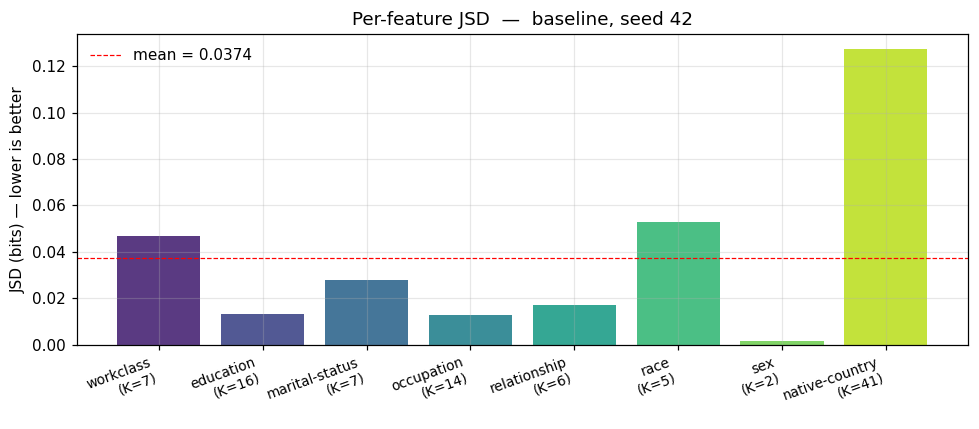

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
xs = np.arange(len(cardinalities))
colors_per_K = plt.cm.viridis(np.linspace(0.1, 0.9, len(cardinalities)))
ax.bar(xs, jsd_per_col, color=colors_per_K, alpha=0.9)
ax.set_xticks(xs)
ax.set_xticklabels([f"{c}\n(K={K})" for c, K in zip(CAT_COLS, cardinalities)],
                   rotation=20, ha='right', fontsize=9)
ax.set_ylabel("JSD (bits) - lower is better")
ax.set_title(f"Per-feature JSD  -  {METHOD}, seed {SEED}")
ax.axhline(jsd_per_col.mean(), color='red', ls='--', lw=0.8,
           label=f"mean = {jsd_per_col.mean():.4f}")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / f"fig_jsd_{METHOD}_seed{SEED}.png", bbox_inches='tight')
plt.show()


### 5b. Correlation matrix L2

In [11]:
cl2 = correlation_l2(
    real_test["x_num"], real_test["x_cat"],
    synth["x_num"],     synth["x_cat"],
)
print(f"correlation_l2(real_test, synth) = {cl2:.4f}")
print(f"(for reference, correlation_l2(real_train, real_test) = 0.21 on this dataset -")
print(f" that's the noise floor from random splitting; good synthetic data stays near it)")


correlation_l2(real_test, synth) = 0.5679
(for reference, correlation_l2(real_train, real_test) = 0.21 on this dataset -
 that's the noise floor from random splitting; good synthetic data stays near it)


### 5c. TSTR - Train on Synthetic, Test on Real

In [12]:
print("Training XGBoost + LR on synthetic data, testing on real test set ...")
tstr_m = tstr(synth, real_test, cardinalities, seed=SEED)

tstr_df = pd.DataFrame({
    "classifier": ["XGBoost", "LogisticRegression"],
    "accuracy":   [tstr_m["xgb_acc"], tstr_m["lr_acc"]],
    "F1":         [tstr_m["xgb_f1"], tstr_m["lr_f1"]],
}).round(4)
print(f"\nUpper bound (train-on-real, test-on-real): XGB 0.87 acc / 0.71 F1, LR 0.84 / 0.64")
print(f"Lower bound (broken-signal):                 ~0.75 acc / 0.00 F1")
tstr_df


Training XGBoost + LR on synthetic data, testing on real test set ...

Upper bound (train-on-real, test-on-real): XGB 0.87 acc / 0.71 F1, LR 0.84 / 0.64
Lower bound (broken-signal):                 ~0.75 acc / 0.00 F1


,classifier,accuracy,F1
0,XGBoost,0.8371,0.6586
1,LogisticRegression,0.8331,0.6454


## 6. Save Metrics

Persist to `outputs/metrics/{METHOD}_seed{SEED}.json` for the comparison notebook.

In [13]:
results = {
    "method":                  METHOD,
    "seed":                    SEED,
    "n_train_steps":           N_TRAIN_STEPS,
    "n_samples":               N_SAMPLES,
    "lambda_mn":               LAMBDA_MN,
    "aux_weight":              AUX_WEIGHT,
    "grad_clip":               GRAD_CLIP,
    "weight_decay":            WEIGHT_DECAY,
    "lr":                      LR,
    "train_time_sec":          train_time,
    "sample_time_sec":         sample_time,
    "final_loss":              float(np.mean([l[1] for l in losses[-100:]])),
    "final_loss_gaussian":     float(np.mean([l[2] for l in losses[-100:]])),
    "final_loss_multinomial":  float(np.mean([l[3] for l in losses[-100:]])),
    "jsd_per_col":             jsd_per_col.tolist(),
    "jsd_mean":                float(jsd_per_col.mean()),
    "correlation_l2":          cl2,
    **tstr_m,
}
METRICS_PATH.write_text(json.dumps(results, indent=2))
print(f"saved {METRICS_PATH}")
print()
print(json.dumps({k: v for k, v in results.items() if k != 'jsd_per_col'}, indent=2))

saved outputs/metrics/baseline_seed42.json

{
  "method": "baseline",
  "seed": 42,
  "n_train_steps": 50000,
  "n_samples": 10000,
  "lambda_mn": 1.0,
  "aux_weight": 1.0,
  "grad_clip": 1.0,
  "weight_decay": 0.0001,
  "lr": 0.001,
  "train_time_sec": 1823.9623000621796,
  "sample_time_sec": 8.887784004211426,
  "final_loss": 1.0683885622024536,
  "final_loss_gaussian": 0.15571850813925267,
  "final_loss_multinomial": 0.91267005443573,
  "jsd_mean": 0.03742827894978355,
  "correlation_l2": 0.5678836050465668,
  "xgb_acc": 0.837055051956666,
  "xgb_f1": 0.6586382584529875,
  "lr_acc": 0.8330753924386469,
  "lr_f1": 0.6453734147487084
}


## 7. Run Additional Seeds (Optional)

For the mean +/- std comparison in `06_comparison.ipynb`, re-execute this notebook with multiple seeds. The cell below loops over `ADDITIONAL_SEEDS` from the config - set it to `[]` to skip.


In [14]:
for extra_seed in ADDITIONAL_SEEDS:
    out_path = Path(f"outputs/metrics/{METHOD}_seed{extra_seed}.json")
    if out_path.exists():
        print(f"[skip] {out_path} already exists"); continue

    print(f"\n=== {METHOD}  seed={extra_seed} ===")
    torch.manual_seed(extra_seed); np.random.seed(extra_seed)

    m_extra = TabDDPMMLP(
        n_num=meta["n_num"], cardinalities=cardinalities, n_classes=2,
        hidden_dim=256, n_layers=3, t_emb_dim=128,
    )
    t0 = time.time()
    losses_e = train(m_extra, gauss_diff, mn_diff, train_loader,
                      n_steps=N_TRAIN_STEPS, lr=LR,
                      weight_decay=WEIGHT_DECAY, lambda_mn=LAMBDA_MN,
                      grad_clip=GRAD_CLIP, log_every=10000,
                      device=DEVICE, seed=extra_seed)
    train_time_e = time.time() - t0

    torch.manual_seed(extra_seed + 10000)
    y_e = (torch.rand(N_SAMPLES, device=DEVICE) < class_p).long()
    t0 = time.time()
    xn, xc = sample(m_extra, gauss_diff, mn_diff,
                    n_samples=N_SAMPLES, y=y_e, device=DEVICE)
    sample_time_e = time.time() - t0
    synth_e = {"x_num": xn.cpu().numpy(), "x_cat": xc.cpu().numpy(),
               "y": y_e.cpu().numpy()}

    jsd_e  = per_column_jsd(real_test["x_cat"], synth_e["x_cat"], cardinalities)
    cl2_e  = correlation_l2(real_test["x_num"], real_test["x_cat"],
                             synth_e["x_num"],   synth_e["x_cat"])
    tstr_e = tstr(synth_e, real_test, cardinalities, seed=extra_seed)

    res_e = {
        "method": METHOD, "seed": extra_seed,
        "n_train_steps": N_TRAIN_STEPS, "n_samples": N_SAMPLES,
        "lambda_mn": LAMBDA_MN, "aux_weight": AUX_WEIGHT,
        "grad_clip": GRAD_CLIP, "weight_decay": WEIGHT_DECAY, "lr": LR,
        "train_time_sec": train_time_e, "sample_time_sec": sample_time_e,
        "final_loss":            float(np.mean([l[1] for l in losses_e[-100:]])),
        "final_loss_gaussian":   float(np.mean([l[2] for l in losses_e[-100:]])),
        "final_loss_multinomial":float(np.mean([l[3] for l in losses_e[-100:]])),
        "jsd_per_col":  jsd_e.tolist(),
        "jsd_mean":     float(jsd_e.mean()),
        "correlation_l2": cl2_e,
        **tstr_e,
    }
    out_path.write_text(json.dumps(res_e, indent=2))
    print(f"  saved {out_path}  (JSD mean = {jsd_e.mean():.4f}, XGB F1 = {tstr_e['xgb_f1']:.3f})")

print("\nDone. See 06_comparison.ipynb to aggregate across methods and seeds.")



=== baseline  seed=1 ===
  step  10000  loss=1.1249  (g=0.1922  m=0.9327)  325.8s
  step  20000  loss=1.0940  (g=0.1735  m=0.9205)  651.4s
  step  30000  loss=1.0802  (g=0.1651  m=0.9151)  987.7s
  step  40000  loss=1.0713  (g=0.1593  m=0.9121)  1330.3s
  step  50000  loss=1.0665  (g=0.1565  m=0.9100)  1663.8s
  saved outputs/metrics/baseline_seed1.json  (JSD mean = 0.0378, XGB F1 = 0.637)

=== baseline  seed=7 ===
  step  10000  loss=1.1245  (g=0.1920  m=0.9325)  339.4s
  step  20000  loss=1.0949  (g=0.1747  m=0.9202)  674.1s
  step  30000  loss=1.0810  (g=0.1656  m=0.9154)  1007.9s
  step  40000  loss=1.0720  (g=0.1598  m=0.9122)  1336.9s
  step  50000  loss=1.0663  (g=0.1563  m=0.9100)  1671.8s
  saved outputs/metrics/baseline_seed7.json  (JSD mean = 0.0381, XGB F1 = 0.660)

Done. See 06_comparison.ipynb to aggregate across methods and seeds.
